### Импорт библиотек и параметры

Импорт библиотек

In [ ]:
!pip install python-docx
!pip install -U transformers
!pip install -q trl bert-score openai
!pip uninstall -y trl
!pip install trl==0.11.3
!pip install -q accelerate>=1.8.0
!pip install -q bitsandbytes>=0.46.1

import time
import random
import re
import pandas as pd
from docx import Document
import numpy as np
from datasets import Dataset

import torch
torch.cuda.empty_cache()

import torch
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead
from transformers import AutoTokenizer, BitsAndBytesConfig
from bert_score import BERTScorer
import openai
from datasets import Dataset
import numpy as np
import gc
from tqdm import tqdm

Found existing installation: trl 0.11.3
Uninstalling trl-0.11.3:
  Successfully uninstalled trl-0.11.3
  Using cached trl-0.11.3-py3-none-any.whl.metadata (12 kB)
Using cached trl-0.11.3-py3-none-any.whl (316 kB)


Настройки API и других параметров лосса

In [ ]:
USE_LLM_REWARD = True
OPENROUTER_API_KEY = "код скрыт"
JUDGE_MODEL = "openai/gpt-oss-120b:free"
LLM_CALL_EVERY_N_STEPS = 1
EPOCHS_NUM = 3
MODEL_TO_LEARN = "Qwen/Qwen2.5-3B-Instruct"
LLM_MAX_RETRIES = 5
LLM_BASE_DELAY = 1.0
last_llm_score = 0.0

bertscorer = BERTScorer(lang="ru", rescale_with_baseline=False, device='cpu')

# Клиент OpenRouter
if USE_LLM_REWARD:
    openrouter_client = openai.OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY
    )

### Преобразование данных для обучения

Чтение транскриптов и кодировок, сохранение в одной таблице

In [ ]:
def parse_pul_intervyu(filename):
    doc = Document(filename)
    paragraphs = [para.text.strip() for para in doc.paragraphs if para.text.strip()]
    if not paragraphs:
        return []

    global_topic = ""
    if not re.match(r'^Интервью\s+\d+', paragraphs[0]):
        global_topic = paragraphs[0]

    interviews = []
    current_interview = None
    in_transcript = False

    for text in paragraphs:
        if text == global_topic:
            continue
        match = re.match(r'^Интервью\s+(\d+)', text)
        if match:
            if current_interview:
                interviews.append(current_interview)
            interview_num = match.group(1)
            current_interview = {'interview_num': interview_num, 'topic': global_topic, 'transcript': ''}
            in_transcript = True
        elif current_interview and in_transcript:
            if current_interview['transcript']:
                current_interview['transcript'] += '\n' + text
            else:
                current_interview['transcript'] = text
    if current_interview:
        interviews.append(current_interview)
    return interviews

def parse_kodirovki(filename):
    doc = Document(filename)
    paragraphs = [para.text.strip() for para in doc.paragraphs if para.text.strip()]
    interviews = []
    current_interview = None
    for text in paragraphs:
        match = re.match(r'^Интервью\s+(\d+)', text)
        if match:
            if current_interview:
                interviews.append(current_interview)
            interview_num = match.group(1)
            current_interview = {'interview_num': interview_num, 'coding_text': ''}
        elif current_interview:
            if current_interview['coding_text']:
                current_interview['coding_text'] += '\n' + text
            else:
                current_interview['coding_text'] = text
    if current_interview:
        interviews.append(current_interview)
    return interviews

files = [
    ('pul_intervyu_1.docx', 'kodirovki_pfi_2023.docx', 'result1.xlsx'),
    ('pul_intervyu_2.docx', 'kodirovki_pfi_2024.docx', 'result2.xlsx'),
    ('pul_intervyu_3.docx', 'kodirovki_sp_2024.docx', 'result3.xlsx'),
    ('pul_intervyu_4.docx', 'kodirovki_pfi_2025.docx', 'result4.xlsx')
]

all_dfs = []
for trans_file, code_file, out_file in files:
    data1 = parse_pul_intervyu(trans_file)
    data2 = parse_kodirovki(code_file)
    df1 = pd.DataFrame(data1)
    df2 = pd.DataFrame(data2)
    merged = pd.merge(df1, df2, on='interview_num', how='outer')
    merged['sort_key'] = merged['interview_num'].apply(lambda x: int(x) if str(x).isdigit() else 0)
    merged = merged.sort_values('sort_key').drop('sort_key', axis=1).fillna('')

    result = merged[['topic', 'interview_num', 'transcript', 'coding_text']].copy()
    result.insert(0, 'Индекс', range(len(result)))
    result.columns = ['Индекс','Тема интервью', 'Порядковый номер интервью', 'Транскрипт интервью', 'Кодирование интервью']
    result.to_excel(out_file, index=False)
    all_dfs.append(result)
    print(result.head())

full_dataset = pd.concat(all_dfs, ignore_index=True)
full_dataset.insert(0, 'Общий номер', range(len(full_dataset)))
full_dataset.to_excel('full_interviews_dataset.xlsx', index=False)
print(f"Общий датасет: {len(full_dataset)} интервью")

    Индекс                                      Тема интервью  \
0        0  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
11       1  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
22       2  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
23       3  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
24       4  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   

   Порядковый номер интервью  \
0                          1   
11                         2   
22                         3   
23                         4   
24                         5   

                                  Транскрипт интервью  \
0   Интервьюер: Так, все, все записи начались. Сна...   
11  Интервьюер: Смотри, вначале расскажи, пожалуйс...   
22  Интервьюер: Так, тогда начинаем. Расскажи спер...   
23  Интервьюер: Тогда, наверное, начнем. Сперва мо...   
24  Интервьюер: Для начала расскажи о себе. Скольк...   

                                 Кодирование интервью  
0   **Общий код 1

Извлечение кодировок для обучающего датасета

In [ ]:
def extract_general_codes(coding_text):
    if pd.isna(coding_text) or not coding_text.strip():
        return []
    pattern = r'\*\*Общий код \d+:[^**]+\*\*'
    general_codes = re.findall(pattern, coding_text)
    general_codes = [code[2:-2].strip() for code in general_codes]
    return general_codes

def prepare_training_data(full_df):
    training_data = []
    for _, row in full_df.iterrows():
        if pd.notna(row['Кодирование интервью']) and row['Кодирование интервью'].strip():
            training_data.append({
                'id': row['Общий номер'],
                'task': 'code_generation',
                'input_text': f"{row['Тема интервью']}\n\nТранскрипт: {row['Транскрипт интервью']}",
                'target': row['Кодирование интервью']
            })
            general_codes = extract_general_codes(row['Кодирование интервью'])
            if general_codes:
                codes_list = "; ".join(general_codes)
                training_data.append({
                    'id': row['Общий номер'],
                    'task': 'text_markup_with_codes',
                    'input_text': f"Тема: {row['Тема интервью']}\nТранскрипт: {row['Транскрипт интервью']}\nОбщие коды: {codes_list}",
                    'target': row['Кодирование интервью']
                })
    return pd.DataFrame(training_data)

data = prepare_training_data(full_dataset)
data = data[data['task']=='code_generation']
data.head()

,id,task,input_text,target
0,0,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
2,1,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
4,2,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
6,3,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
8,4,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."


Разделение на train, val, test по ID интервью

In [ ]:
def split_dataset_properly(train_df):
    if 'id' not in train_df.columns:
        return None, None, None
    interview_ids = train_df['id'].unique()
    np.random.shuffle(interview_ids)
    n_train = int(0.7 * len(interview_ids))
    n_val = int(0.15 * len(interview_ids))
    train_ids = interview_ids[:n_train]
    val_ids = interview_ids[n_train:n_train+n_val]
    test_ids = interview_ids[n_train+n_val:]

    train_df_split = train_df[train_df['id'].isin(train_ids)].copy()
    val_df_split = train_df[train_df['id'].isin(val_ids)].copy()
    test_df_split = train_df[train_df['id'].isin(test_ids)].copy()

    print(f"Train: {len(train_df_split)} примеров")
    print(f"Val:   {len(val_df_split)} примеров")
    print(f"Test:  {len(test_df_split)} примеров")
    return train_df_split, val_df_split, test_df_split

train_df, val_df, test_df = split_dataset_properly(data)

train_df.to_pickle('train_split.pkl')
val_df.to_pickle('val_split.pkl')
test_df.to_pickle('test_split.pkl')

train_dataset = Dataset.from_pandas(train_df.iloc[:-1])
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

Train: 105 примеров
Val:   22 примеров
Test:  23 примеров


### Кастомный reward

Функция получения оценки DeepSeek с кэшировнаием

In [ ]:
llm_cache = {}

def get_llm_score(generated_text, source_text, topic):
    cache_key = (generated_text, source_text, topic)
    if cache_key in llm_cache:
        return llm_cache[cache_key]

    if not USE_LLM_REWARD:
        return None

    model = JUDGE_MODEL

    prompt = f"""Ты - социолог-эксперт в открытом кодировании интервью.
Тема интервью: {topic}
Текст интервью: {source_text}

Сгенерированные коды и цитаты (в формате <код>цитата</код>):
{generated_text}

Оцени результат по трём критериям (каждый от 0 до 1):
1. Релевантность - насколько код соответствует содержанию фрагмента интервью с учётом темы.
2. Когерентность - насколько формулировка кода грамматически корректна и стилистически приемлема.
3. Теоретический инсайт - степень соответствия кода концептуальным ожиданиям.

Ответ дай строго в формате: число, число, число (например: 0.85, 0.90, 0.75). Не пиши никаких пояснений."""

    max_retries = 5
    base_delay = 1.0
    max_delay = 30.0

    for attempt in range(max_retries):
        try:
            response = openrouter_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=50
            )
            # Проверка структуры ответа
            if response and hasattr(response, 'choices') and response.choices:
                content = response.choices[0].message.content
                if content:
                    # Ищем все числа в ответе (целые и с плавающей точкой)
                    numbers = re.findall(r"(\d+\.?\d*)", content)
                    if len(numbers) >= 3:
                        try:
                            scores = [float(n) for n in numbers[:3]]
                            mean_score = np.mean(scores)
                            mean_score = max(0.0, min(1.0, mean_score))
                            llm_cache[cache_key] = mean_score
                            return mean_score
                        except ValueError:
                            print(f"LLM warning: non-numeric numbers: {numbers}", flush=True)
                    else:
                        print(f"LLM warning: expected 3 numbers, got {len(numbers)}. Content: {content[:200]}", flush=True)
                else:
                    print("LLM warning: empty content", flush=True)
            else:
                print("LLM warning: invalid response structure", flush=True)
            return None

        except Exception as e:
            is_retryable = False
            if hasattr(e, 'status_code'):
                if e.status_code == 429 or (500 <= e.status_code < 600):
                    is_retryable = True
            elif '429' in str(e) or 'rate limit' in str(e).lower():
                is_retryable = True

            if not is_retryable or attempt == max_retries - 1:
                print(f"LLM error (final): {type(e).__name__}: {e}", flush=True)
                return None
            delay = min(base_delay * (2 ** attempt), max_delay)
            jitter = random.uniform(0, 0.1 * delay)
            wait_time = delay + jitter
            print(f"LLM error (retryable): {e}. Retrying in {wait_time:.2f}s... (attempt {attempt+1}/{max_retries})", flush=True)
            time.sleep(wait_time)

    return None

Функия для подсчета reward

In [ ]:
def compute_reward(generated, target, source_text, topic, use_llm=True, last_llm=None):
    # BERTScore F1 (всегда считаем)
    _, _, bert_f1 = bertscorer.score([generated], [target])
    bert_reward = bert_f1.item()

    if use_llm:
        # Если передан last_llm, используем его (пришло из generate_and_reward)
        if last_llm is not None:
            llm_reward = last_llm
        else:
            # Вычисляем новый LLM score
            llm_reward = get_llm_score(generated, source_text, topic)
    else:
        llm_reward = 0.0

    total_reward = bert_reward + llm_reward
    return total_reward, bert_reward, llm_reward

### Подготовка к дообучению с PRO

Преобразование датасета в формат PRO

In [ ]:
def build_prompt_for_ppo(example):
    """Формирует промт (query) как в исходном build_prompt, но без ответа"""
    if example['task'] == 'code_generation':
        instruction = """Ты — эксперт по анализу интервью. Твоя задача — выделить в тексте интервью тематические коды и разметить его.

Формат ответа (строго соблюдай этот формат):
**Общий код 1: [название общего кода]**
"[точная цитата из интервью]" - **[название конкретного кода] (конкретный код)**
"[еще одна цитата]" - **[другой конкретный код] (конкретный код)**

**Общий код 2: [название следующего общего кода]**
"[цитата]" - **[конкретный код] (конкретный код)**

Пример правильной разметки:
**Общий код 1: Представления о работе и критерии выбора места работы**
"Для меня, в первую очередь, важен коллектив" - **Приоритет коллектива (конкретный код)**
"Чтобы я могла как-то развиваться" - **Возможность развития (конкретный код)**
"Зарплата, ну, чтобы не совсем уж мизерно" - **Приемлемый уровень зарплаты (конкретный код)**

**Общий код 2: Отношение к работе и мотивация**
"Я не хочу работать с людьми, которых я ненавижу" - **Важность комфортной атмосферы (конкретный код)**
"Чтобы я могла что-то новое узнавать" - **Стремление к обучению (конкретный код)**

Теперь выполни разметку для следующего интервью. ВАЖНО: В ответе должны быть только коды и цитаты, без лишних слов и повторений."""

    prompt = f"""<|im_start|>system
{instruction}<|im_end|>
<|im_start|>user

Текст интервью:
{example['input_text']}

Пожалуйста, выполни разметку интервью в указанном формате.<|im_end|>
<|im_start|>assistant
{example['target']}<|im_end|>"""

    return prompt

def prepare_ppo_dataset(hf_dataset, tokenizer):
    queries = []
    targets = []
    for ex in hf_dataset:
        query = build_prompt_for_ppo(ex)
        target = ex['target']
        queries.append(query)
        targets.append(target)
    return Dataset.from_dict({"query": queries, "target": targets})

# Загружаем временный токенизатор (только для структуры)
temp_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-2B")
temp_tokenizer.pad_token = temp_tokenizer.eos_token

ppo_train_dataset = prepare_ppo_dataset(train_dataset, temp_tokenizer)
ppo_val_dataset = prepare_ppo_dataset(val_dataset, temp_tokenizer)
print(f"PPO train dataset size: {len(ppo_train_dataset)}")
print(f"PPO val dataset size: {len(ppo_val_dataset)}")

PPO train dataset size: 105
PPO val dataset size: 22


Извлечение source_text и topic из input_text

In [ ]:
def extract_source_and_topic(input_text):
    """
    Извлекает транскрипт и тему из поля input_text.
    Формат input_text: "Тема: ...\nТранскрипт: ..." или "...\n\nТранскрипт: ..."
    """
    topic = ""
    transcript = ""
    lines = input_text.split('\n')
    for line in lines:
        if line.startswith("Тема:"):
            topic = line.replace("Тема:", "").strip()
        elif line.startswith("Транскрипт:"):
            transcript = line.replace("Транскрипт:", "").strip()
        elif "Транскрипт:" in line and not transcript:
            transcript = line.split("Транскрипт:")[-1].strip()

    # Если тема не найдена, возможно она в первой строке до "Транскрипт:"
    if not topic and "Транскрипт:" in input_text:
        parts = input_text.split("Транскрипт:")
        if len(parts) > 0:
            first_part = parts[0].strip()
            if first_part.startswith("Тема:"):
                topic = first_part.replace("Тема:", "").strip()
            else:
                # Тема может быть просто первым предложением
                topic = first_part.split('\n')[0].strip()
    return transcript, topic

# Добавляем колонки source_text и topic в ppo_train_dataset
source_texts = []
topics = []
for ex in train_dataset:   # используем оригинальный train_dataset (с полями input_text, target, task, id)
    src, top = extract_source_and_topic(ex["input_text"])
    source_texts.append(src)
    topics.append(top)

ppo_train_dataset = ppo_train_dataset.add_column("source_text", source_texts)
ppo_train_dataset = ppo_train_dataset.add_column("topic", topics)

print("Пример:")
print("query:", ppo_train_dataset[0]["query"][:200], "...")
print("target:", ppo_train_dataset[0]["target"][:200], "...")
print("source_text:", ppo_train_dataset[0]["source_text"][:100], "...")
print("topic:", ppo_train_dataset[0]["topic"])

Пример:
query: <|im_start|>system
Ты — эксперт по анализу интервью. Твоя задача — выделить в тексте интервью тематические коды и разметить его.

Формат ответа (строго соблюдай этот формат):
**Общий код 1: [название  ...
target: **Общий код 1: Поколенческие характеристики, ценности и жизненные ориентиры**
"Мне кажется, большинство особо не стремятся там вот срочно, прямо сейчас там жениться, замуж, там детей и так далее. Вот. ...
source_text: Интервьюер: Так, все, все записи начались. Сначала я попрошу тебя рассказать какую-то основную инфор ...
topic: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И УСТОЙЧИВОСТЬ РОССИЙСКОЙ МОЛОДЕЖИ


Загрузка модели с Value Head и LoRA (8-bit)

In [ ]:
model_name = MODEL_TO_LEARN
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model.gradient_checkpointing_enable()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params} ({100*trainable_params/total_params:.2f}% of {total_params})")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Trainable parameters: 311408641 (18.33% of 1698674689)


Настройка PPOConfig

In [ ]:
from trl import PPOConfig, PPOTrainer

ppo_config = PPOConfig(
    learning_rate=1e-6,
    batch_size=2,
    mini_batch_size=2,
    gradient_accumulation_steps=1,
    ppo_epochs=1,
    log_with=None,
    project_kwargs={"logging_dir": "./ppo_logs"},
    seed=42,
    optimize_cuda_cache=True,
    # Только поддерживаемые параметры:
    init_kl_coef=0.5,
    target_kl=6.0,
)

ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
)

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:273: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(


Функция генерации и reward (с кэшем генераций)

In [ ]:
generation_cache = {}

def generate_and_reward(queries, targets, source_texts, topics, use_llm=True):
    global last_llm_score

    all_outputs = []
    device = next(model.parameters()).device

    query_tensors = []
    for query in queries:
        inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256).to(device)
        query_tensors.append(inputs)

    for inp in query_tensors:
        with torch.no_grad():
            gen_ids = model.generate(
                **inp,
                max_new_tokens=64,
                do_sample=True,
                top_p=0.9,
                temperature=0.5,
                pad_token_id=tokenizer.pad_token_id,
            )
        output_text = tokenizer.decode(gen_ids[0][inp["input_ids"].shape[1]:], skip_special_tokens=True)
        all_outputs.append(output_text)

    rewards_total = []
    rewards_bert = []
    rewards_llm = []

    for out, target, src, topic in zip(all_outputs, targets, source_texts, topics):
        _, _, bert_f1 = bertscorer.score([out], [target])
        bert_reward = bert_f1.item()

        if use_llm:
            new_llm = get_llm_score(out, src, topic)
            if new_llm is not None:
                last_llm_score = new_llm
            llm_reward = last_llm_score
        else:
            llm_reward = last_llm_score

        total_reward = bert_reward + llm_reward

        rewards_total.append(torch.tensor(total_reward, dtype=torch.float32))
        rewards_bert.append(bert_reward)
        rewards_llm.append(llm_reward)

    response_tensors = [tokenizer.encode(out, return_tensors="pt", truncation=True, max_length=256).to(device)[0] for out in all_outputs]
    return query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm

### Обучение

Цикл PPO обучения

In [ ]:
torch.cuda.empty_cache()
gc.collect()

405

In [ ]:
epochs = EPOCHS_NUM
total_examples = len(ppo_train_dataset)
batch_size = ppo_config.batch_size
num_full_batches = total_examples // batch_size

all_losses = []
all_rewards_total = []
all_rewards_bert = []
all_rewards_llm = []

for epoch in range(epochs):
    generation_cache.clear()
    for batch_idx in tqdm(range(num_full_batches), desc=f"Epoch {epoch+1}"):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size

        queries = []
        targets = []
        src_texts = []
        topics_list = []

        for idx in range(start_idx, end_idx):
            batch_item = ppo_train_dataset[idx]
            queries.append(batch_item["query"])
            targets.append(batch_item["target"])
            src_texts.append(batch_item["source_text"])
            topics_list.append(batch_item["topic"])

        # Определяем, нужно ли вызывать LLM на этом батче
        use_llm_here = (batch_idx % LLM_CALL_EVERY_N_STEPS == 0) and USE_LLM_REWARD

        query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm = generate_and_reward(
            queries, targets, src_texts, topics_list, use_llm=use_llm_here
        )
        query_ids = [q["input_ids"][0] for q in query_tensors]

        # Шаг PPO
        train_stats = trainer.step(query_ids, response_tensors, rewards_total)

        # Извлекаем loss
        loss_value = train_stats.get('ppo/loss/total', train_stats.get('loss', 0.0))
        if isinstance(loss_value, torch.Tensor):
            loss_value = loss_value.item()

        # Сохраняем метрики (берём первый элемент батча для простоты)
        all_losses.append(loss_value)
        all_rewards_total.append(rewards_total[0].item())
        all_rewards_bert.append(rewards_bert[0])
        all_rewards_llm.append(rewards_llm[0])

        del query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm, query_ids
        torch.cuda.empty_cache()
        gc.collect()

# Сохраняем логи
log_df = pd.DataFrame({
    'step': range(len(all_losses)),
    'loss': all_losses,
    'reward_total': all_rewards_total,
    'reward_bert': all_rewards_bert,
    'reward_llm': all_rewards_llm
})
log_df.to_csv('training_log.csv', index=False)
print("Логи сохранены в training_log.csv")

Epoch 1:  19%|█▉        | 10/52 [04:17<17:52, 25.54s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.15 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 1:  50%|█████     | 26/52 [11:14<12:17, 28.36s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.03 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 2:  27%|██▋       | 14/52 [05:26<15:09, 23.94s/it]

LLM warning: invalid response structure


Epoch 2:  58%|█████▊    | 30/52 [12:21<08:28, 23.12s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.20 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 3:  90%|█████████ | 47/52 [18:52<02:08, 25.77s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -4.17 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 3: 100%|██████████| 52/52 [21:24<00:00, 24.71s/it]

Логи сохранены в training_log.csv


### График метрик после обучения

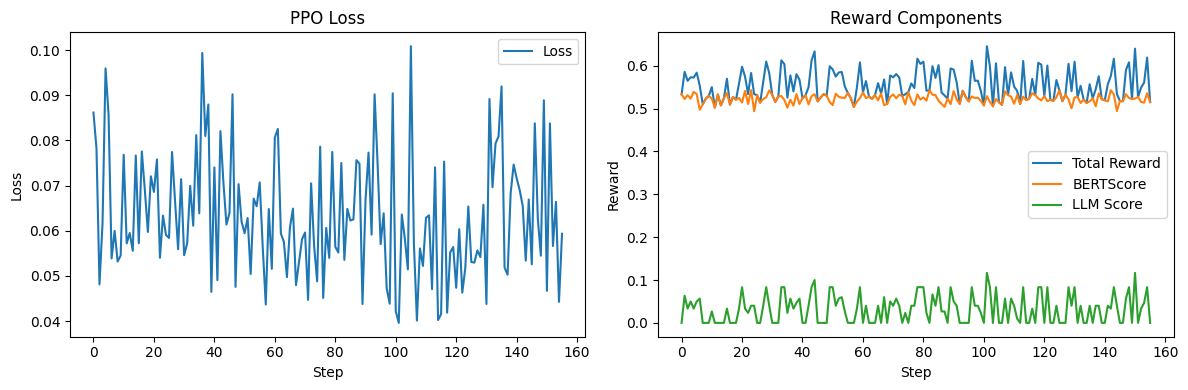

In [ ]:
import matplotlib.pyplot as plt

log_df = pd.read_csv('training_log.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(log_df['step'], log_df['loss'], label='Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('PPO Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(log_df['step'], log_df['reward_total'], label='Total Reward')
plt.plot(log_df['step'], log_df['reward_bert'], label='BERTScore')
plt.plot(log_df['step'], log_df['reward_llm'], label='LLM Score')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Components')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

Сохранение LoRA-адаптера

In [ ]:
model.save_pretrained("./qwen_ppo_lora")
tokenizer.save_pretrained("./qwen_ppo_lora")
print("Модель сохранена в ./qwen_ppo_lora")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена в ./qwen_ppo_lora


Оценка на тестовой выборке

In [ ]:
ppo_test_dataset = prepare_ppo_dataset(test_dataset, tokenizer)

# Извлекаем source_text и topic для теста
test_source_texts = []
test_topics = []
for ex in test_dataset:
    src, top = extract_source_and_topic(ex["input_text"])
    test_source_texts.append(src)
    test_topics.append(top)

ppo_test_dataset = ppo_test_dataset.add_column("source_text", test_source_texts)
ppo_test_dataset = ppo_test_dataset.add_column("topic", test_topics)

device = next(model.parameters()).device

predictions = []
all_rewards_total = []
all_rewards_bert = []
all_rewards_llm = []

for batch_idx, batch in enumerate(tqdm(ppo_test_dataset, desc="Evaluating on test")):
    query = batch["query"]
    target = batch["target"]
    src = batch["source_text"]
    topic = batch["topic"]

    inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    pred = tokenizer.decode(gen_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    # BERTScore
    _, _, bert_f1 = bertscorer.score([pred], [target])
    bert_reward = bert_f1.item()

    # LLM score
    if USE_LLM_REWARD:
        new_llm = get_llm_score(pred, src, topic)
        if new_llm is not None:
            last_llm_score = new_llm
        llm_reward = last_llm_score
    else:
        llm_reward = 0.0

    total_reward = bert_reward + llm_reward

    all_rewards_total.append(total_reward)
    all_rewards_bert.append(bert_reward)
    all_rewards_llm.append(llm_reward)

    predictions.append({
        "query": query,
        "prediction": pred,
        "target": target,
        "source_text": src,
        "topic": topic,
        "reward_total": total_reward,
        "reward_bert": bert_reward,
        "reward_llm": llm_reward
    })

pred_df = pd.DataFrame(predictions)

print("\n=== Test Metrics ===")
print(f"Average Total Reward: {np.mean(all_rewards_total):.4f}")
print(f"Average BERTScore: {np.mean(all_rewards_bert):.4f}")
print(f"Average LLM Score: {np.mean(all_rewards_llm):.4f}")

pred_df.to_csv('test_predictions.csv', index=False)
print("\nPredictions saved to test_predictions.csv")
pred_df.head()

Evaluating on test: 100%|██████████| 23/23 [07:03<00:00, 18.41s/it]



=== Test Metrics ===
Average Total Reward: 0.4767
Average BERTScore: 0.4664
Average LLM Score: 0.0103

Predictions saved to test_predictions.csv


,query,prediction,target,source_text,topic,reward_total,reward_bert,reward_llm
0,<|im_start|>system\nТы — эксперт по анализу ин...,Как a number of following numbers in a high o...,"**Общий код 1: Поколенческие характеристики, ц...","Интервьюер: Смотри, вначале расскажи, пожалуйс...","ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И...",0.473960,0.473960,0.0
1,<|im_start|>system\nТы — эксперт по анализу ин...,Как a number of following numbers in a high o...,"**Общий код 1: Поколенческие характеристики, ц...",Интервьюер: Для начала расскажи о себе. Скольк...,"ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И...",0.460509,0.460509,0.0
2,<|im_start|>system\nТы — эксперт по анализу ин...,Как a number of following numbers in a high o...,"**Общий код 1: Поколенческие характеристики, ц...","Интервьюер: Ну да. Так, привет. Теперь меня сл...","ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И...",0.471975,0.471975,0.0
3,<|im_start|>system\nТы — эксперт по анализу ин...,Как a number of following numbers in a high o...,"**Общий код 1: Поколенческие характеристики, ц...","Интервьюер: Ну, что, Галь, расскажи немножечко...","ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И...",0.475569,0.475569,0.0
4,<|im_start|>system\nТы — эксперт по анализу ин...,Как a number of following numbers in a high o...,"**Общий код 1: Поколенческие характеристики, ц...","Интервьюер: Так, начнём. Я буду периодически п...","ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И...",0.474126,0.474126,0.0


Просмотр примера предсказания

In [ ]:
print(pred_df.iloc[-1]["prediction"])

Е a number of following numbers in a high of the following a complex numbers are a function with a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


In [ ]:
for i in pred_df['prediction']:
    print(i, '\n', '*****************************************', '\n')

 Как a number of following numbers in a high of the following a complex numbers are a function with a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 
 ***************************************** 

 Как a number of following numbers in a high of the following a complex numbers are a function with a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 
 ***************************************** 

 Как a number of following numbers in a high of the following a complex numbers are a function with a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 